# Analyse exploratoire (EDA) — `cleaned_data_diabetes.csv`

Had notebook kayحاول يجاوب على سؤال واحد: **أي الرسومات (graphes) تفيدني باش نفهم data ديالي مزيان**, قبل الكلاستيرينغ والكلاسيفيكاسيون.

Chaque section = **سؤال** + **الرسم** + **كيفاش تقراه**. ماشي لازم تستعمل الكل، كل واحد عندو دور مختلف.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)


In [4]:
df = pd.read_csv('C:/Users/safiy/Desktop/les brief/DiabetesRisk-AI/data/processed/cleaned_data_diabetes.csv')
print('Dimensions :', df.shape)
df.head()


Dimensions : (768, 8)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,125.333333,33.6,0.627,50.0
1,1.0,85.0,66.0,29.0,66.666667,26.6,0.351,31.0
2,8.0,183.0,64.0,30.0,195.000000,23.3,0.672,32.0
3,1.0,89.0,66.0,23.0,94.000000,28.1,0.167,21.0
4,0.0,137.0,40.0,35.0,168.000000,43.1,1.200,33.0


In [5]:
print('Types :\n', df.dtypes)
print('\nManquants :\n', df.isna().sum())
print('\nDoublons :', df.duplicated().sum())
df.describe().T


Types :
 Pregnancies                 float64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
dtype: object

Manquants :
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Doublons : 0


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.837240,3.344157,0.000,1.000000,3.0000,6.00000,13.500
Glucose,768.0,121.580295,30.530240,44.000,99.000000,117.0000,141.00000,199.000
BloodPressure,768.0,72.318142,11.819796,40.000,64.000000,72.0000,80.00000,104.000
SkinThickness,768.0,29.054688,9.224872,7.000,22.333333,29.0000,35.00000,57.000
Insulin,768.0,145.061361,78.353867,14.000,83.500000,132.0000,189.50000,360.625
BMI,768.0,32.369162,6.684704,18.200,27.500000,32.3000,36.60000,50.250
DiabetesPedigreeFunction,768.0,0.458914,0.285596,0.078,0.243750,0.3725,0.62625,1.200
Age,768.0,33.199870,11.628404,21.000,24.000000,29.0000,41.00000,66.500


## 1. أش شكل كل متغير؟ (Distribution — Histogramme)

**السؤال اللي كايجاوب عليه** : أي المتغيرات متمركزة (symétrique), أي واحد منحرف (asymétrique / skewed)؟
هاد الشي كايوجهك واش تحتاج transformation (log) قبل Scaling.


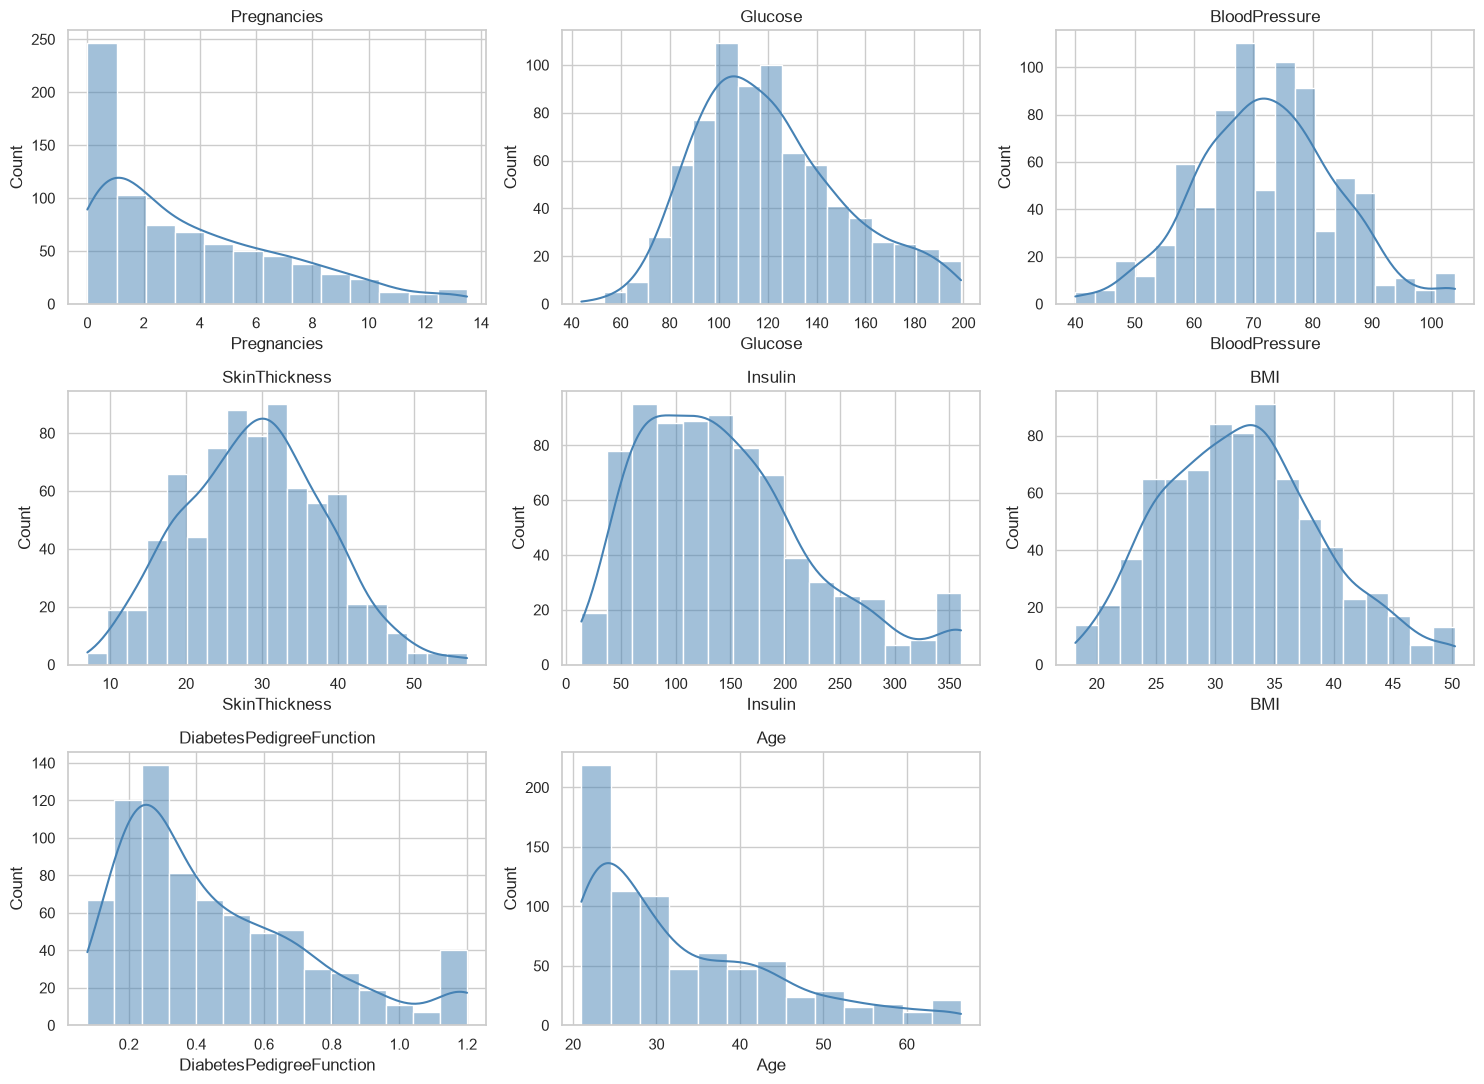

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flat, df.columns):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
for ax in axes.flat[len(df.columns):]:
    ax.axis('off')
plt.tight_layout()
plt.show()


In [7]:
skew = df.skew().sort_values(ascending=False)
skew.to_frame('skewness')


,skewness
Age,1.067170
DiabetesPedigreeFunction,1.024428
Insulin,0.858145
Pregnancies,0.853962
Glucose,0.531919
BMI,0.354334
SkinThickness,0.144776
BloodPressure,0.106532


**كيفاش تقراها** : skewness قريبة من 0 = distribution متوازنة. skewness > 1 = منحرفة بزاف (غالبا `Insulin` و `DiabetesPedigreeFunction`) → خاصها `log1p()` قبل الـ Scaler، حيت KMeans كايخدم بالمسافات (distances) وكايتأثر بزاف بالمتغيرات المنحرفة.


## 2. واش كاين قيم متطرفة؟ (Outliers — Boxplot)

**السؤال** : أي المتغيرات فيها نقط بعيدة على الباقي (outliers)؟ هاد الشي كايأثر بزاف على KMeans (حساس للـ outliers) وعلى المتوسطات (Étape 4 — تحديد الـ cluster à haut risque).


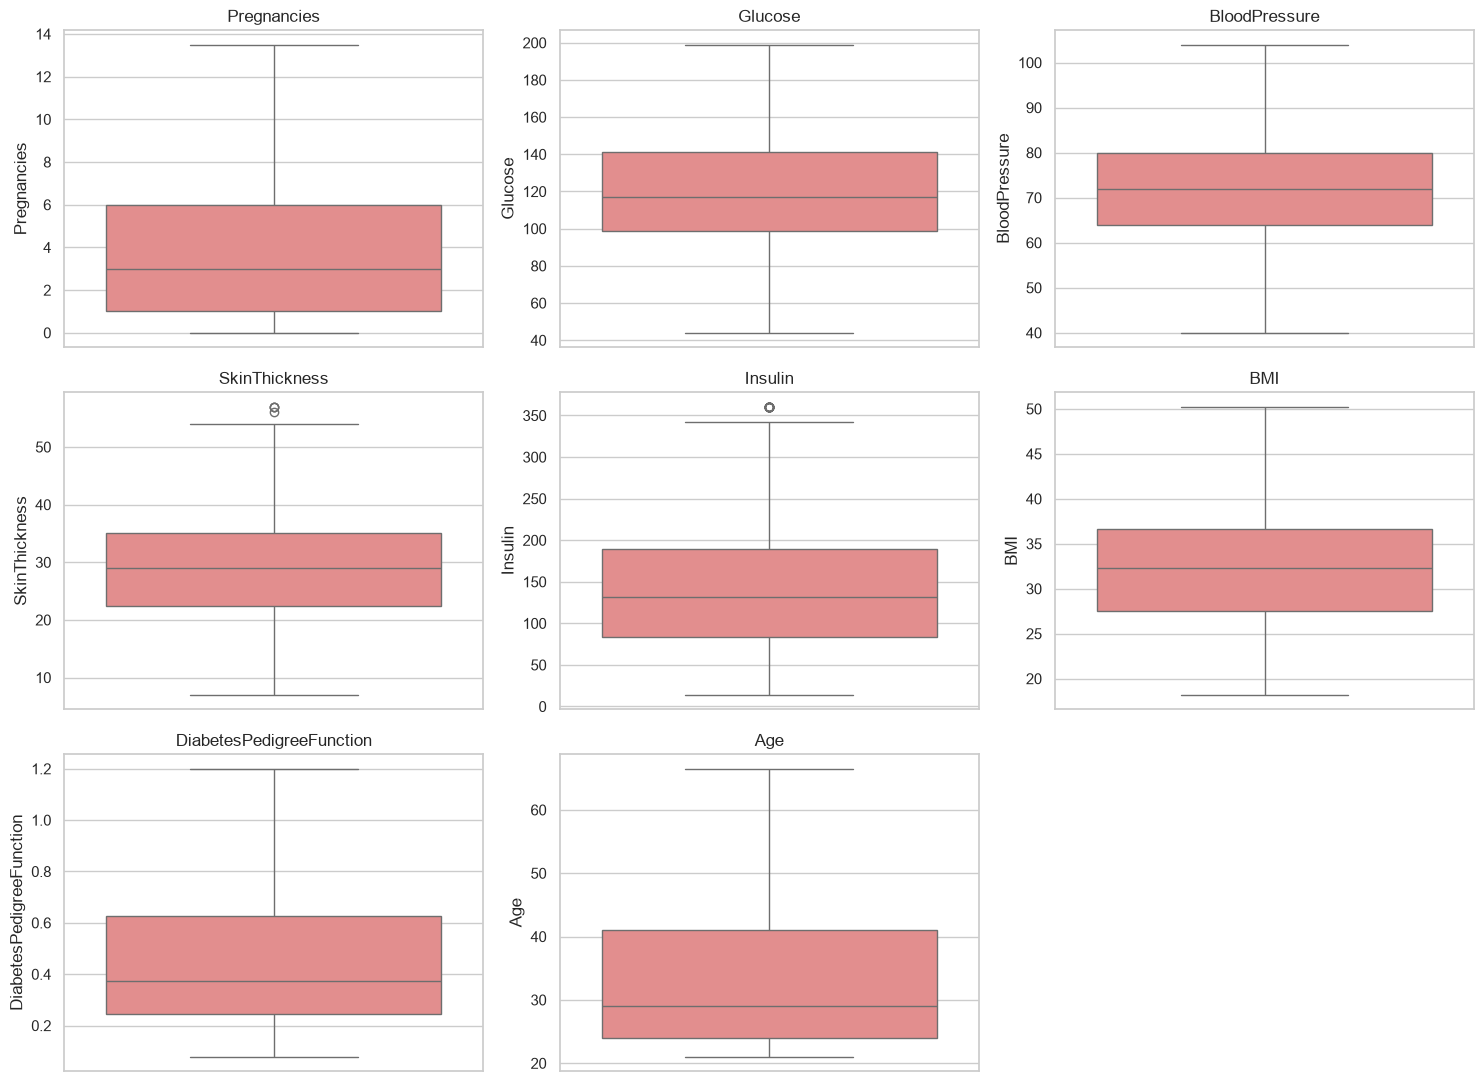

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flat, df.columns):
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(col)
for ax in axes.flat[len(df.columns):]:
    ax.axis('off')
plt.tight_layout()
plt.show()


In [9]:
def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return int(((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum())

pd.Series({c: iqr_outliers(df[c]) for c in df.columns}, name='outliers_IQR').sort_values(ascending=False)


Insulin                     25
SkinThickness                4
Glucose                      0
Pregnancies                  0
BloodPressure                0
BMI                          0
DiabetesPedigreeFunction     0
Age                          0
Name: outliers_IQR, dtype: int64

**كيفاش تقراها** : عدد كبير من outliers (غالبا `Insulin`, `SkinThickness`) = خاصك تقرر إيلا غادي تحيدهم, تكابيهم (capping), ولا تخليهم. قرارك هادا خاصو يتبرر فـ README.


## 3. واش الكولونات مرتبطين مع بعضياتهم؟ (Corrélation — Heatmap)

**السؤال** : واش كاين متغيرات كايعطيو نفس المعلومة (redondance)؟ إيلا كورّيلاسيون قريبة من 1 أو -1، واحد منهم زائد.


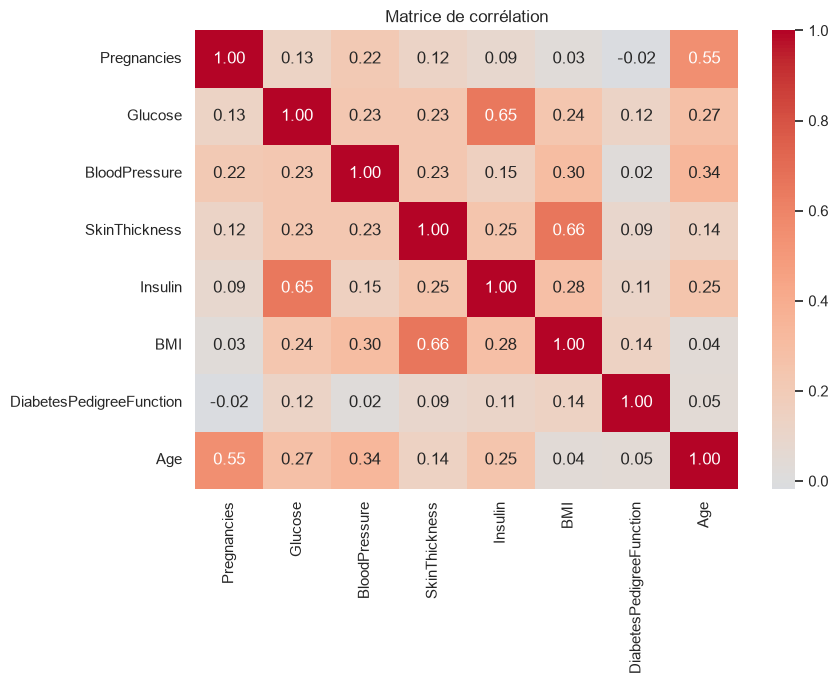

In [10]:
corr = df.corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()


**كيفاش تقراها** : هنا ماكاينش كورّيلاسيون فوق 0.9، إذن ماكاينش تكرار قوي. الكورّيلاسيونات المتوسطة (مثلا `SkinThickness` و `BMI`) عاديين فـ data كلينيكية، ماخاصكش تحيد عليهم غير بهاد السبب.


## 4. كيفاش المتغيرات مرتبطين فـ شكل (relation) — Pairplot

**السؤال** : واش كاين علاقة غير خطية (non linéaire) أو تجمعات بصرية (visual clusters) بين جوج متغيرات؟ الـ heatmap كاتعطيك رقم غير، الـ pairplot كايوريك الشكل.


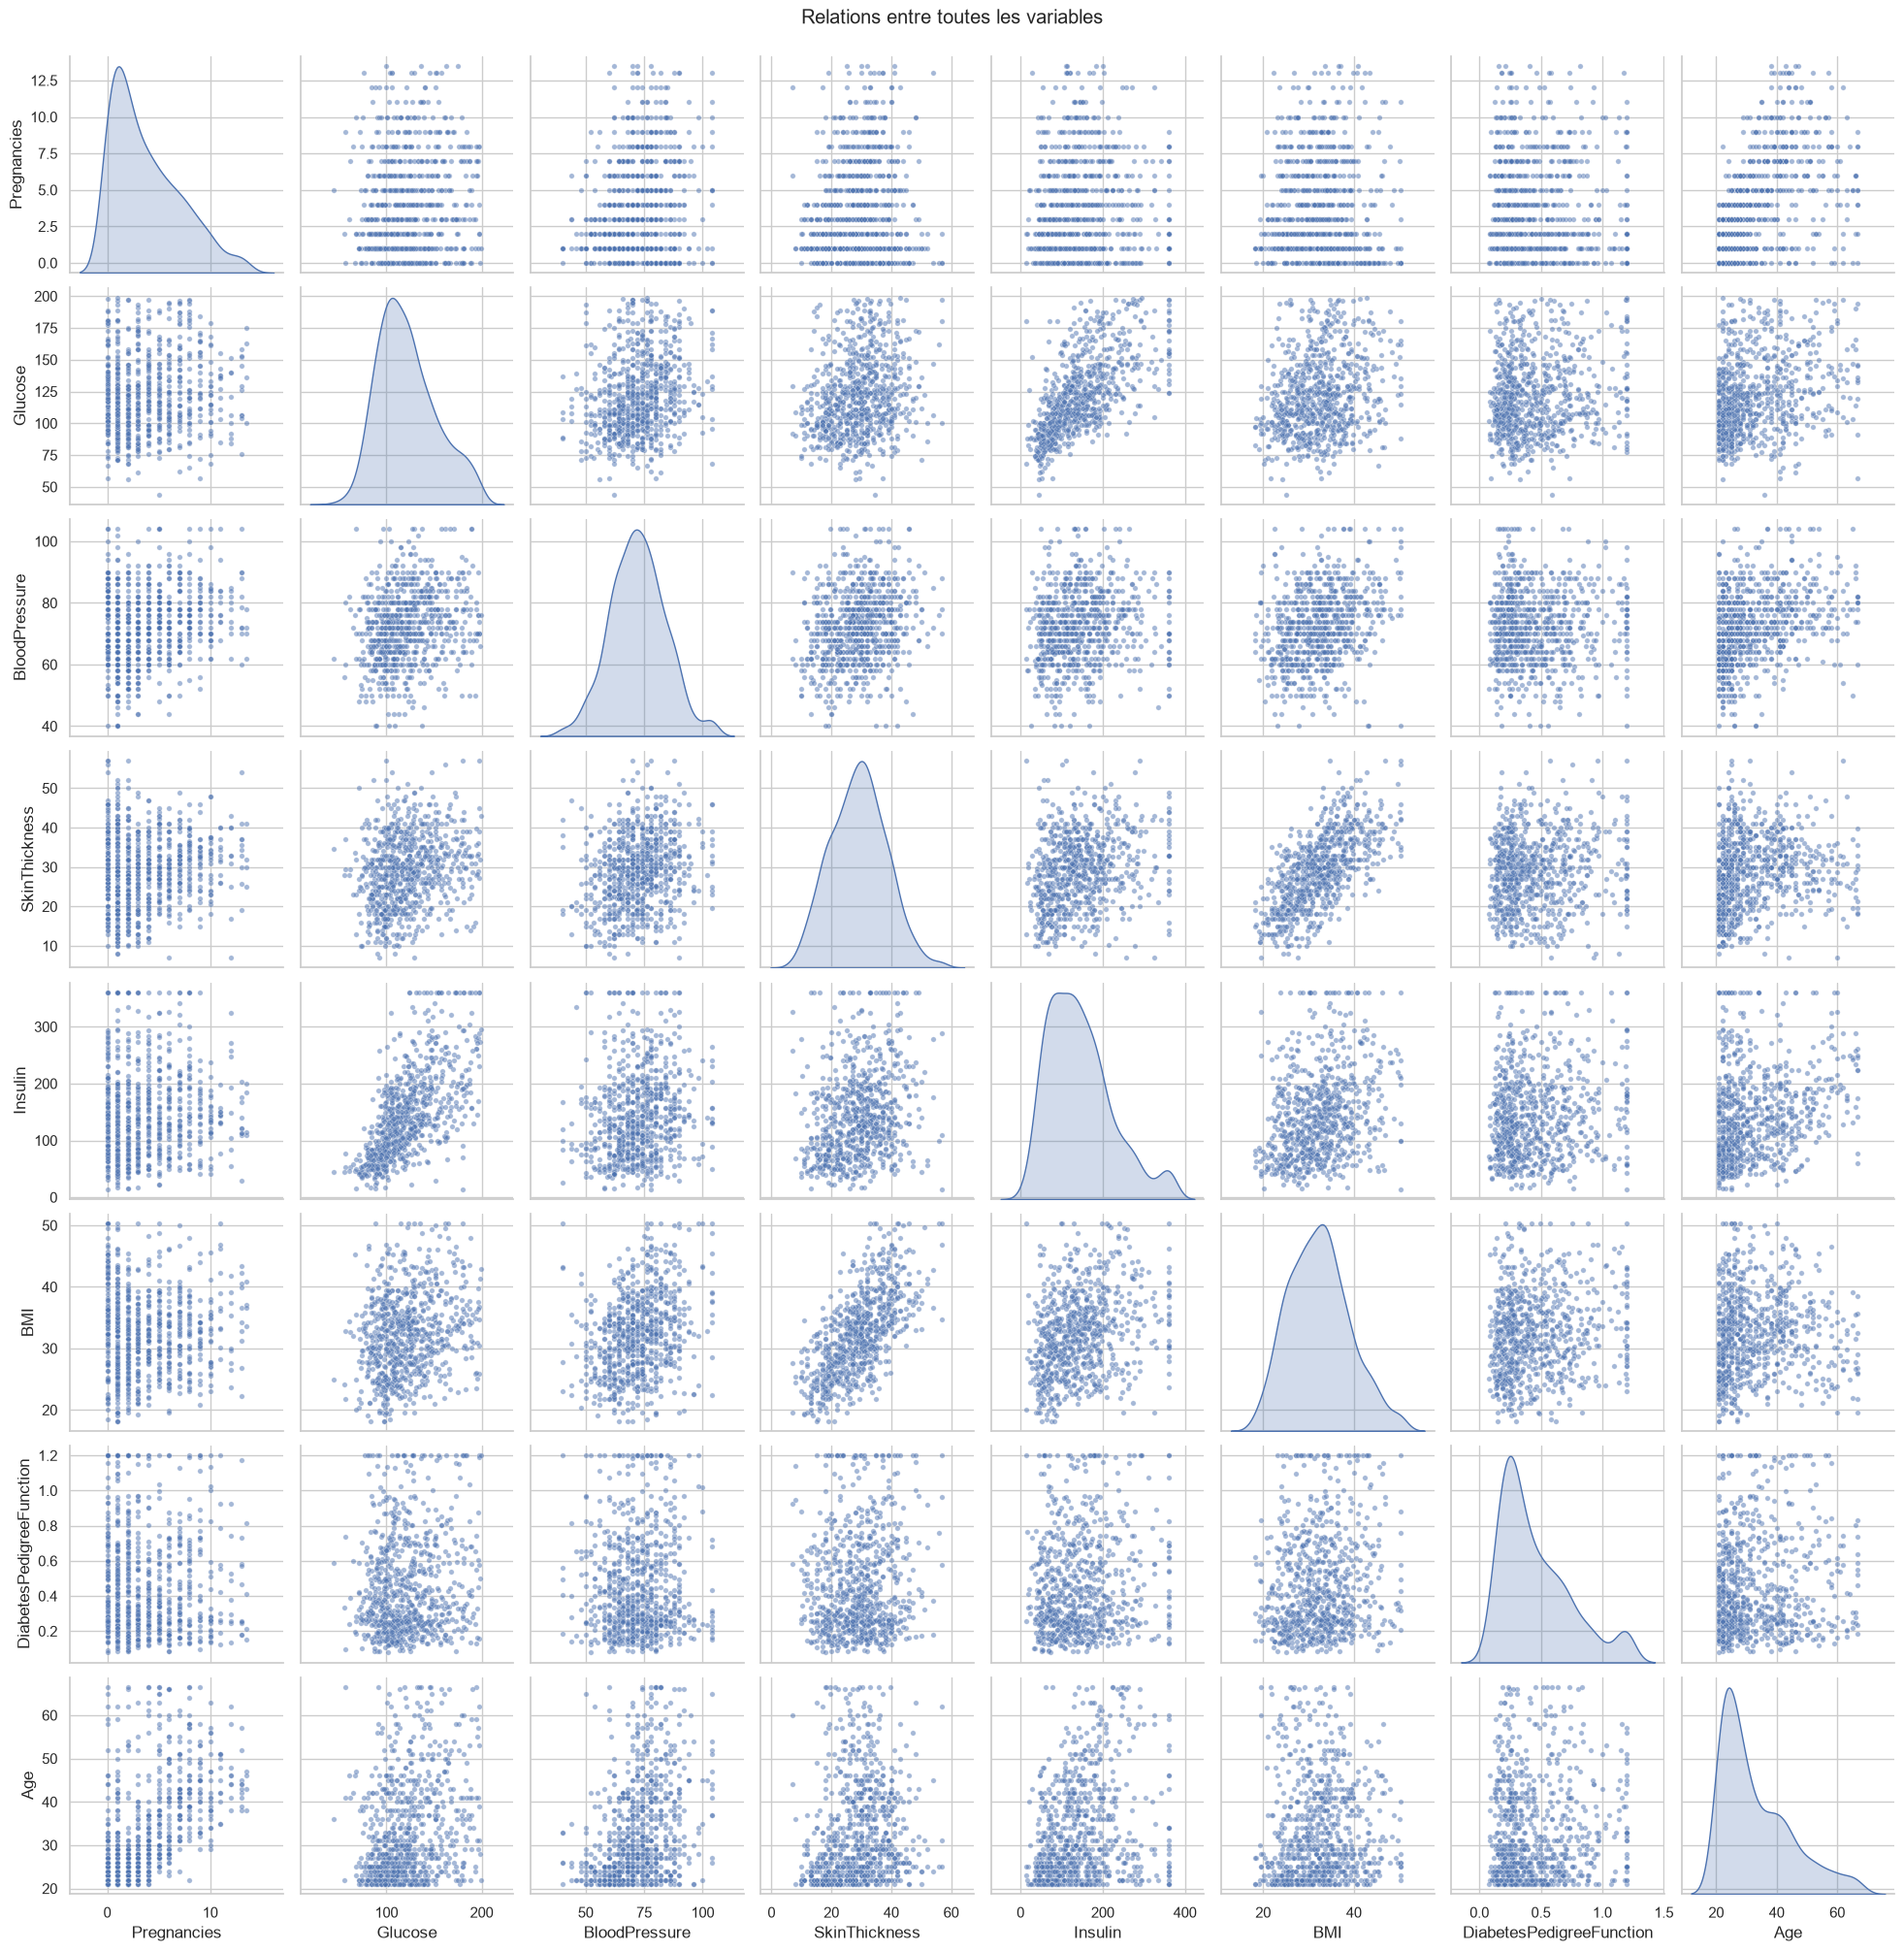

In [11]:
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.5, 's': 15})
plt.suptitle('Relations entre toutes les variables', y=1.01)
plt.show()


**كيفاش تقراها** : دور على نقط اللي كايبانو فـ "سحابتين" بدل سحابة وحدة (مثلا `Glucose` vs `Insulin`) — هاد الشي مؤشر أن ممكن يكون كاين profils مختلفين (prometteur للـ clustering).


## 5. واش المتغيرات خاصهم Standardisation؟ (Variance brute)

**السؤال** : واش بعض المتغيرات غادي "يهيمنو" على KMeans غير حيت الوحدة (échelle) ديالهم كبيرة؟


In [12]:
df.var().sort_values(ascending=False).to_frame('variance_brute')


,variance_brute
Insulin,6139.328465
Glucose,932.095529
BloodPressure,139.707577
Age,135.219778
SkinThickness,85.098266
BMI,44.685264
Pregnancies,11.183383
DiabetesPedigreeFunction,0.081565


**كيفاش تقراها** : `Insulin` عندها variance فـ المئات، `DiabetesPedigreeFunction` عندها variance صغيرة بزاف — ماشي لأنها "ماهمتش"، غير لأن الوحدة ديالها صغيرة. هادشي كايبرر `StandardScaler` قبل أي clustering، باش كلشي يولي على نفس المقياس.


## 6. بعد الـ Scaling : واش data فيها بنية (structure) باينة؟ (PCA 2D)

**السؤال** : إيلا نقلّصو 7 متغيرات لـ 2 بعد (PC1, PC2), واش غادي نشوفو مجموعات باينة بالعين قبل حتى ندوزو KMeans؟

⚠️ **مهم** : PCA هنا غير لـ **visualisation**. الـ clustering خاصو يتدار على المتغيرات الأصلية المعيارية (scaled), ماشي على PC1/PC2 — باش تقدر بعدين تفسر الـ clusters بـ Glucose/BMI/DPF الحقيقيين.


Variance expliquée par PC1, PC2 : [0.32422167 0.18420948]
Total : 0.5084311410737157


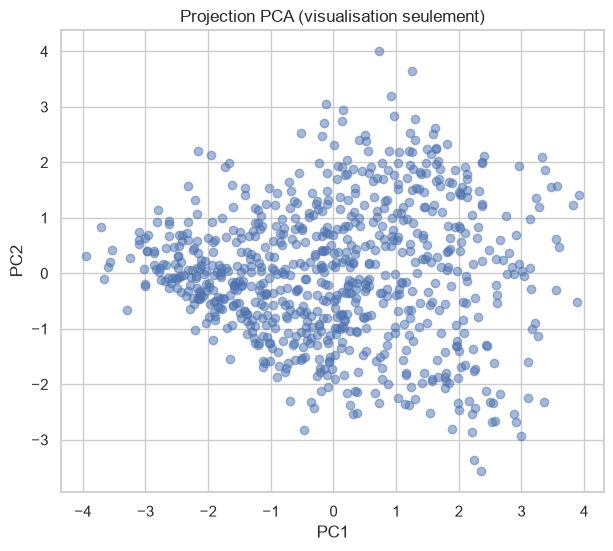

In [13]:
X_scaled = StandardScaler().fit_transform(df)

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)
print('Variance expliquée par PC1, PC2 :', pca.explained_variance_ratio_)
print('Total :', pca.explained_variance_ratio_.sum())

plt.figure(figsize=(7, 6))
plt.scatter(pcs[:, 0], pcs[:, 1], alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Projection PCA (visualisation seulement)')
plt.show()


**كيفاش تقراها** : إيلا `Total` (variance expliquée) صغيرة (مثلا < 50%), معناه PC1/PC2 ماكايلخصوش data مزيان، والصورة لي كتبان فيها "ضبابية" (chevauchement) عادية وماشي مشكل فـ الكلاستيرينغ الحقيقي (اللي خدام على 7 متغيرات كاملين).


## 7. شحال من Cluster خاصني؟ (Méthode du coude + Silhouette)

**السؤال** : قبل ما نختار `k` (عدد الكلاستر) بالراس، كيفاش نبرر الاختيار ديالي؟ هادي بالضبط الإيتاب 3 ديال l'énoncé.


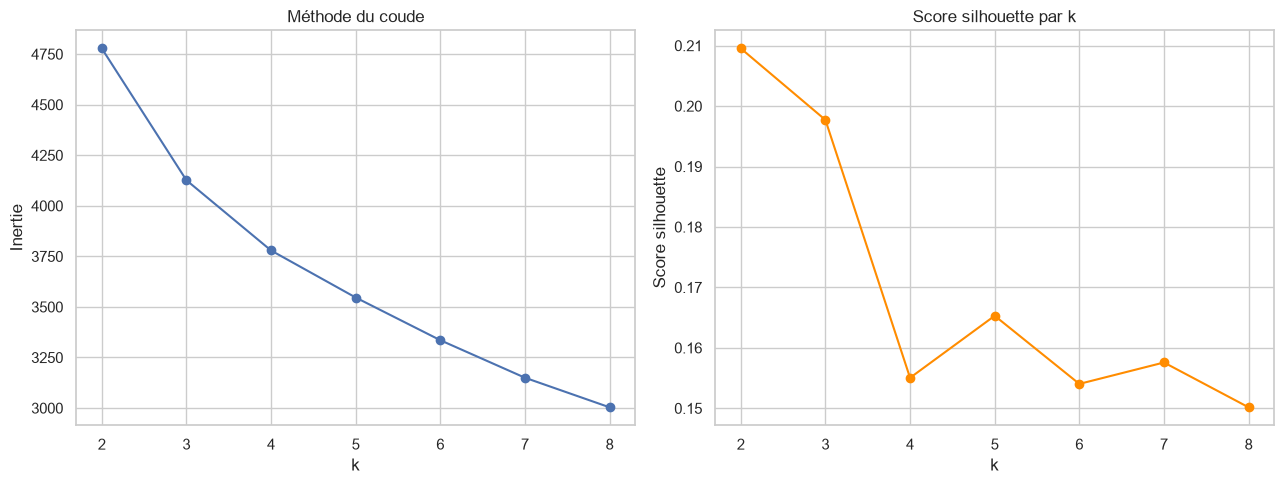

,k,inertie,silhouette
0,2,4778.119277,0.209536
1,3,4126.405638,0.197706
2,4,3779.040660,0.155043
3,5,3546.478879,0.165304
4,6,3335.389249,0.154035
5,7,3149.934769,0.157578
6,8,3003.614887,0.150160


In [14]:
inertias, silhouettes = [], []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Méthode du coude')

axes[1].plot(list(k_range), silhouettes, marker='o', color='darkorange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score silhouette')
axes[1].set_title('Score silhouette par k')
plt.tight_layout()
plt.show()

pd.DataFrame({'k': list(k_range), 'inertie': inertias, 'silhouette': silhouettes})


**كيفاش تقراها** :
- **Coude (inertie)** : دور على النقطة اللي بعدها الخط كايولي "مسطح" (plat) — زيادة k ماعادش كتنقص الإنيرسي بزاف.
- **Silhouette** : الأعلى (الأقرب لـ 1) هو الأحسن. إيلا كاين قمة واضحة (مثلا k=2 أو k=3), هادوك هوما المرشحين.
- خاص `k` المختار يكون **اتفاق بين الجوج graphes**, ماشي غير واحد منهم.


## خلاصة — أي graphe نستعمل فأي وقت؟

| سؤالك | الـ graphe |
|---|---|
| شكل كل متغير (symétrique/skewed)؟ | Histogramme + KDE |
| كاين valeurs aberrantes؟ | Boxplot + IQR |
| كاين redondance بين متغيرات؟ | Heatmap de corrélation |
| كيفاش جوج متغيرات مرتبطين بصريا؟ | Pairplot |
| خاصني Standardisation؟ | Variance brute |
| data فيها بنية قبل الكلاستيرينغ؟ | PCA 2D (visualisation غير) |
| شحال من cluster نختار؟ | Coude + Silhouette |
